# Synopsis

Out of the breast cancer dataset of the scikit-learn library, this project aims to
- perform a pricipal component analysis (PCA Supervised) to find 2 eigenvectors of the dataset covariance matrix, which has the maximum correlation with the target / label, and then,
    - Hoping the variance in the features best explains the target and so, eigen vectors belongs to the maximum two eigen values  :)
- regress by
    - constructing a linear probability analysis via linear algebra, normal equation, which is $x = (A^T.A)^{-1}.A^T.b$, and pass the regression through sigmoid function, and then,
    - performing a logistic regression analysis via scikit-learn library, and lastly,
- evaluate classification power of the model (from logistic regression) by **roc_auc score, roc_auc curve, accuracy score and confusion matrix.**

# Import

In [1]:
import pandas as pd
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc("axes.spines", top=False, right=False)
plt.style.use("ggplot")

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Load Dataset (x)

## x (features)

In [2]:
cancer = load_breast_cancer()
x= pd.DataFrame(cancer["data"], columns=cancer["feature_names"])
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## y (target)

In [4]:
y = pd.DataFrame(cancer["target"], columns=["Cancer?"])
y

,Cancer?
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


# Preparation

## Scale features: z scaling as the units differ between features

In [5]:
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x))
x_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## Find the covariance df of the x / features dataframe

In [6]:
x_scaled_cov = x_scaled.cov()
x_scaled_cov.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.001761,0.324352,0.999612,0.989095,0.170882,0.507015,0.677955,0.823977,0.148001,-0.312179,...,0.971246,0.297531,0.966836,0.942739,0.119827,0.414191,0.527839,0.745524,0.164242,0.007078
1,0.324352,1.001761,0.330113,0.321651,-0.023430,0.237119,0.302950,0.293981,0.071527,-0.076572,...,0.353194,0.913650,0.358670,0.344151,0.077640,0.278319,0.301555,0.295836,0.105193,0.119415
2,0.999612,0.330113,1.001761,0.988244,0.207643,0.557917,0.717396,0.852475,0.183349,-0.261937,...,0.971183,0.303572,0.972095,0.943207,0.150814,0.456577,0.564872,0.772599,0.189448,0.051108
3,0.989095,0.321651,0.988244,1.001761,0.177340,0.499379,0.687191,0.824718,0.151559,-0.283608,...,0.964441,0.287995,0.960808,0.960902,0.123740,0.391098,0.513508,0.723288,0.143823,0.003744
4,0.170882,-0.023430,0.207643,0.177340,1.001761,0.660284,0.522903,0.554670,0.558757,0.585822,...,0.213495,0.036135,0.239273,0.207082,0.806742,0.473300,0.435691,0.503939,0.395004,0.500195


## Find the eigenvalues and eigenvectors of the covariance df

In [7]:
eig_val, eig_vec = np.linalg.eig(x_scaled_cov)

## Find the principal components and their correlation with the target feature

In [8]:
pcs = x_scaled @ eig_vec
pcs.corrwith(y.iloc[:, 0]).to_frame("correlation").abs().sort_values(by="correlation", ascending=False).head()

,correlation
0,0.785491
1,0.188363
2,0.164782
3,0.127566
14,0.106170


1. What is seen above is the descending sort of absolute correlation values between principal components each and the target.
2. As seen, the eigenvectors indexed **0 and 1** are the ones that have the most correlation with the target.
    - These are the ones with the largest eigen values already.
4. Therefore, analysis will continue with these two principal components.

## Construct new coordinates / dataframe out of the selected eigenvectors

In [9]:
x_new = x_scaled @ eig_vec[:, :2]
x_new.columns = ["first_pc", "second_pc"]
x_new.head()

,first_pc,second_pc
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


## Add intercept to the principal components dataframe

In [10]:
x_new["intercept"] = 1
x_new = x_new[["intercept", "first_pc", "second_pc"]]
x_new.head()

,intercept,first_pc,second_pc
0,1,9.192837,1.948583
1,1,2.387802,-3.768172
2,1,5.733896,-1.075174
3,1,7.122953,10.275589
4,1,3.935302,-1.948072


# Regression

## by Normal Equation $x = (A^T.A)^{-1}.A^T.b$ and then through sigmoid function

In [11]:
linear_eq = np.linalg.inv(x_new.T @ x_new) @ x_new.T @ y
linear_eq.index = ["intercept", "first_pc_coef", "second_pc_coef"]
linear_eq

,Cancer?
intercept,0.627417
first_pc_coef,-0.104209
second_pc_coef,0.038175


- So, the regression equation is:

  Cancer or not = 0.627417 + first_pc * (-0.104209) + second_pc * (0.038175)
> When the first row values of the features are put into the equation, the predicted target emerges as -0.2562 agains the actual target 0. 

 - Pass the predictions through sigmoid function to find probabilities

In [12]:
y_pred_raw = 0.627417 + (-0.104209) * x_new.first_pc.values + 0.038175 * x_new.second_pc.values

In [13]:
y_pred_prob = 1 / (1 + np.exp(-y_pred_raw))

In [14]:
y_pred_prob = pd.DataFrame(y_pred_prob, columns=["probabilities for positive"])
y_pred_prob.head()

,probabilities for positive
0,0.436305
1,0.558416
2,0.497212
3,0.568912
4,0.535678


## by Logistic regression

In [15]:
model = LogisticRegression(fit_intercept=False, penalty="l1", solver="liblinear")
model.fit(x_new, y.iloc[:, 0])

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred_prob = model.predict_proba(x_new)[:, 1]
y_pred_prob = pd.DataFrame(y_pred_prob, columns=["probabilities for positive"])
y_pred_prob.head()

,probabilities for positive
0,6.406542e-08
1,1.280036e-04
2,2.661072e-06
3,6.850541e-02
4,4.148622e-05


# Evaluation of the model (IAW the Logistic Regression)

## Evaluation metrics

### Roc-Auc Score

In [17]:
roc_auc_score = roc_auc_score(y, y_pred_prob)
print("Roc-Auc score of the model is: ", round(roc_auc_score, 4), ". Pretty well!")

Roc-Auc score of the model is:  0.9899 . Pretty well!


### Roc-Auc Curve

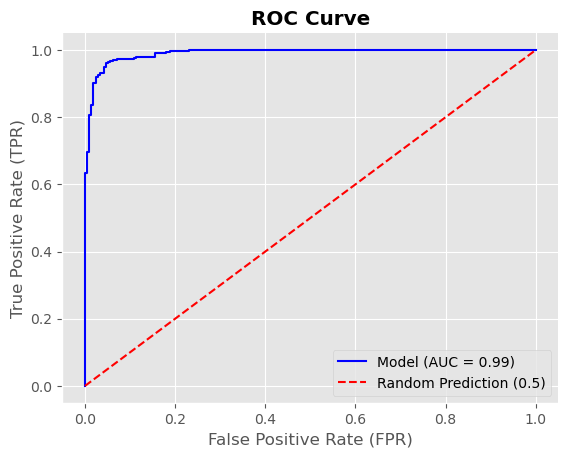

In [18]:
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)

plt.plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Prediction (0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve', fontweight="bold")
plt.legend();

#### Best Threshold (Youden's J.)

In [19]:
# Youden's J (TPR - FPR)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

print(f"Optimal Eşik (Youden's J): {thresholds[best_idx]:.4f}")
print(f"Bu Eşikteki TPR (Sensitivity): {tpr[best_idx]:.4f}")
print(f"Bu Eşikteki FPR (1 - Specificity): {fpr[best_idx]:.4f}")

Optimal Eşik (Youden's J): 0.5587
Bu Eşikteki TPR (Sensitivity): 0.9608
Bu Eşikteki FPR (1 - Specificity): 0.0472


### Accuracy Score

In [20]:
y_pred = (y_pred_prob > thresholds[best_idx]).astype("int")
accuracy_score = accuracy_score(y, y_pred)
print("Accuracy score (TP + TN, ratio) is: ", round(accuracy_score, 4))

Accuracy score (TP + TN, ratio) is:  0.9561


### Confusion Matrix

In [21]:
cm = confusion_matrix(y, y_pred)
cm

array([[202,  10],
       [ 15, 342]])

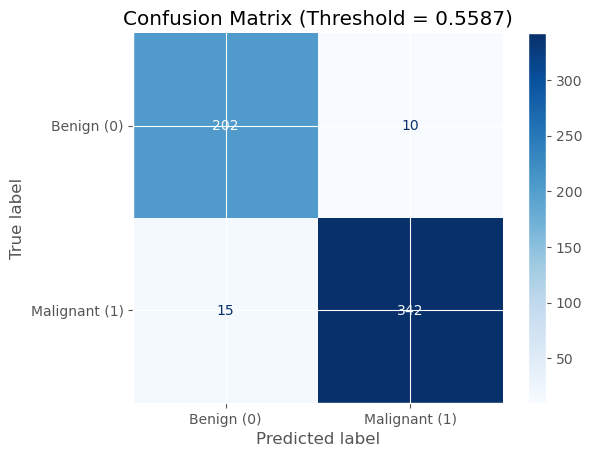

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix (Threshold = {round(thresholds[best_idx], 4)})");

# Final Words

From business logic perspective, the mest measures are:
- TPR is 0.96, high enough!
- FNR is 0.04. low enough!